In [46]:
!pip install catboost


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [48]:
!pip install xgboost lightgbm catboost


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, random_state = 42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


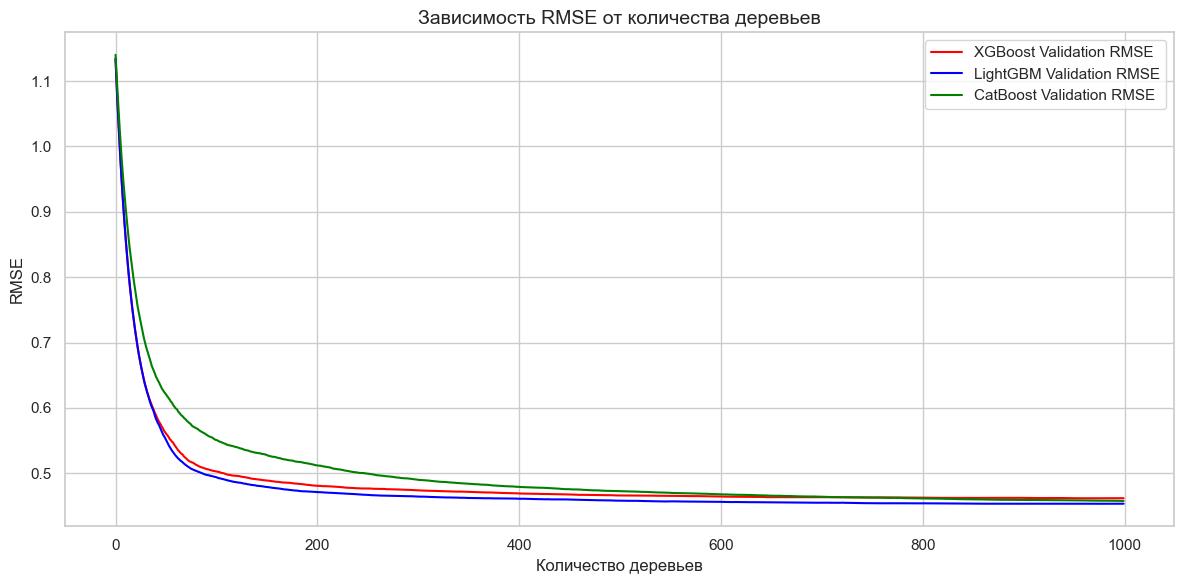

In [50]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators = MAX_TREES, learning_rate = LEARNING_RATE, random_state = 42)
xgb_model.fit(X_train, y_train, eval_set = [(X_val, y_val)], verbose = False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators = MAX_TREES, learning_rate = LEARNING_RATE, random_state = 42, verbose = -1)
lgb_model.fit(X_train, y_train, eval_set= [(X_val, y_val)], eval_metric = 'rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations = MAX_TREES, learning_rate = LEARNING_RATE, eval_metric = 'RMSE', random_seed = 42)
cb_model.fit(X_train, y_train, eval_set = (X_val, y_val), verbose = False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label = 'XGBoost Validation RMSE', color = 'red')
plt.plot(lgb_rmse, label = 'LightGBM Validation RMSE', color = 'blue')
plt.plot(cb_val_rmse, label = 'CatBoost Validation RMSE', color = 'green')

plt.title('Зависимость RMSE от количества деревьев', fontsize = 14)
plt.xlabel('Количество деревьев', fontsize = 12)
plt.ylabel('RMSE', fontsize = 12)
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
SELECTED_N_ESTIMATORS = 400

In [52]:
class MyBoost:
  def __init__(self, n = 400, lr = 0.05, depth = 7, seed = 42) -> None:
      self.n = n
      self.lr = lr
      self.depth = depth
      self.seed = seed
      self.trees = []

  def fit(self, X, y):
    self.initial_leaf = y.mean()
    predictions = np.zeros(len(y)) + self.initial_leaf

    for _ in range(self.n):
      antigrad = y - predictions
      tree = DecisionTreeRegressor(max_depth = self.depth, random_state = self.seed, criterion = "friedman_mse")

      tree.fit(X, antigrad)
      self.trees.append(tree)

      predictions += tree.predict(X) * self.lr

  def predict(self, samples):
    predictions = np.zeros(len(samples)) + self.initial_leaf
    for i in range(self.n):
      predictions += self.lr * self.trees[i].predict(samples)

    return predictions


In [53]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"   Запуск Grid Search для {model_name}   ")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators = SELECTED_N_ESTIMATORS, random_state = 42, n_jobs = -1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators = SELECTED_N_ESTIMATORS, random_state = 42, n_jobs = -1, verbose = -1)
        else:
            model = cb.CatBoostRegressor(**params, iterations = SELECTED_N_ESTIMATORS, random_seed = 42, thread_count = -1, verbose = 0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

   Запуск Grid Search для XGBoost   
Лучший Validation RMSE: 0.4596
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'subsample': 0.8}

   Запуск Grid Search для LightGBM   
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

   Запуск Grid Search для CatBoost   
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [54]:
results = []

for name in['XGBoost', 'LightGBM', 'CatBoost', "MyBoost"]:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators = SELECTED_N_ESTIMATORS, random_state = 42, n_jobs = -1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators = SELECTED_N_ESTIMATORS, random_state = 42, n_jobs = -1, verbose = -1, **params)
    elif name == 'MyBoost':
        model = MyBoost()
    else:
        model = cb.CatBoostRegressor(iterations = SELECTED_N_ESTIMATORS, random_seed = 42, thread_count = -1, verbose = 0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,3.912,0.2888,0.4440,0.8496
1,LightGBM,1.331,0.2862,0.4379,0.8537
2,CatBoost,5.272,0.2967,0.4493,0.8460
3,MyBoost,69.140,0.2956,0.4566,0.8409


---
## Домашнее задание: расширение MyBoost

Добавляем к базовому классу четыре новых возможности:
1. **`subsample`** — стохастический бустинг: каждое дерево обучается на случайной подвыборке строк
2. **`colsample_bytree`** — случайные подпространства: каждое дерево видит только случайное подмножество признаков
3. **`feature_importances_`** — усреднённая важность признаков по всем деревьям ансамбля
4. **Категориальные признаки** — нативная поддержка через OrdinalEncoder внутри пайплайна
5. **(Бонус)** `GBMClassifier` — бустинг для бинарной классификации через log-odds / sigmoid

### Расширенный `MyBoostV2`: subsample, colsample_bytree, feature_importances_, категориальные признаки

In [55]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

class MyBoostV2:
    """
    Градиентный бустинг для регрессии с расширенным функционалом.

    Параметры
    ---------
    n            : int   — число деревьев
    lr           : float — шаг обучения (learning rate)
    depth        : int   — максимальная глубина каждого дерева
    subsample    : float — доля строк (объектов), используемых для обучения каждого дерева (0 < subsample ≤ 1)
    colsample    : float — доля признаков, используемых для обучения каждого дерева (0 < colsample ≤ 1)
    seed         : int   — фиксатор случайности для воспроизводимости
    """

    def __init__(self, n = 400, lr = 0.05, depth = 7,
                 subsample = 1.0, colsample = 1.0, seed = 42):
        self.n          = n
        self.lr         = lr
        self.depth      = depth
        self.subsample  = subsample   # доля строк на каждое дерево
        self.colsample  = colsample   # доля признаков на каждое дерево
        self.seed       = seed
        self.trees      = []          # список обученных деревьев
        self.col_indices = []         # список индексов признаков для каждого дерева

        # для категориальных признаков
        self._encoder    = None       # OrdinalEncoder — подгоняется при fit
        self._cat_cols   = []         # имена/индексы категориальных колонок

    # ── вспомогательный метод: перекодировать категориальные признаки ──
    def _encode_cats(self, X, fit = False):
        """Возвращает np.array, закодировав категориальные колонки."""
        if isinstance(X, np.ndarray):
            # Нет named columns — возвращаем как есть (предполагаем, что уже числовые)
            return X.astype(float)

        X = X.copy()
        cat_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
        self._cat_cols = cat_cols

        if cat_cols:
            if fit:
                self._encoder = OrdinalEncoder(
                    handle_unknown = 'use_encoded_value', unknown_value = -1
                )
                X[cat_cols] = self._encoder.fit_transform(X[cat_cols])
            else:
                if self._encoder is not None:
                    X[cat_cols] = self._encoder.transform(X[cat_cols])

        return X.values.astype(float)

    def fit(self, X, y):
        rng = np.random.RandomState(self.seed)

        # Кодируем категориальные признаки один раз
        X_enc = self._encode_cats(X, fit = True)
        y = np.asarray(y, dtype = float)

        n_samples, n_features = X_enc.shape

        # Начальное предсказание — среднее таргета
        self.initial_leaf = y.mean()
        predictions = np.full(n_samples, self.initial_leaf)

        self.trees      = []
        self.col_indices = []

        for i in range(self.n):
            # ── subsample: выбираем случайные строки ──
            if self.subsample < 1.0:
                row_idx = rng.choice(n_samples,
                                     size = int(n_samples * self.subsample),
                                     replace = False)
            else:
                row_idx = np.arange(n_samples)

            # ── colsample_bytree: выбираем случайные признаки ──
            if self.colsample < 1.0:
                col_idx = rng.choice(n_features,
                                     size = max(1, int(n_features * self.colsample)),
                                     replace = False)
                col_idx = np.sort(col_idx)
            else:
                col_idx = np.arange(n_features)

            self.col_indices.append(col_idx)

            # Антиградиент (псевдо-остатки) на подвыборке
            antigrad = y[row_idx] - predictions[row_idx]

            tree = DecisionTreeRegressor(
                max_depth = self.depth,
                random_state = self.seed + i,   # разные деревья — разный seed
                criterion = 'friedman_mse'
            )
            tree.fit(X_enc[np.ix_(row_idx, col_idx)], antigrad)
            self.trees.append(tree)

            # Обновляем предсказания на ВСЕЙ выборке (важно!)
            predictions += self.lr * tree.predict(X_enc[:, col_idx])

        return self

    def predict(self, X):
        X_enc = self._encode_cats(X, fit=False)
        predictions = np.full(len(X_enc), self.initial_leaf)
        for tree, col_idx in zip(self.trees, self.col_indices):
            predictions += self.lr * tree.predict(X_enc[:, col_idx])
        return predictions

    @property
    def feature_importances_(self):
        """
        Усреднённая важность признаков по всем деревьям ансамбля.

        Логика:
          - У каждого DecisionTreeRegressor есть атрибут feature_importances_
            (нормированный массив длиной = числу признаков ЭТОГО дерева, т.е. len(col_idx))
          - Взвешиваем по learning_rate (вклад каждого дерева пропорционален lr)
          - Распределяем обратно в пространство всех признаков через col_idx
        """
        if not self.trees:
            raise RuntimeError("Модель не обучена. Сначала вызовите fit().")

        # Определяем полное число признаков из первого col_idx
        n_features_total = max(idx.max() for idx in self.col_indices) + 1
        importances = np.zeros(n_features_total)

        for tree, col_idx in zip(self.trees, self.col_indices):
            # tree.feature_importances_ уже нормирован (сумма = 1)
            importances[col_idx] += tree.feature_importances_ * self.lr

        # Нормируем итоговый вектор так, чтобы сумма = 1
        total = importances.sum()
        if total > 0:
            importances /= total

        return importances


#### Быстрая проверка корректности класса

In [56]:
# Проверяем: подгоняем на train_full, тестируем на X_test
# Используем те же данные, что и в лекции

mb2 = MyBoostV2(
    n = 400, lr = 0.05, depth = 7,
    subsample = 0.8,     # 80% строк на каждое дерево
    colsample = 0.8,     # 80% признаков на каждое дерево
    seed = 42
)

t0 = time.time()
mb2.fit(X_train_full, y_train_full)
t_mb2 = time.time() - t0

preds_mb2 = mb2.predict(X_test)
rmse_mb2  = np.sqrt(mean_squared_error(y_test, preds_mb2))
r2_mb2    = r2_score(y_test, preds_mb2)

print(f"MyBoostV2 (subsample=0.8, colsample=0.8)")
print(f"  Время обучения : {t_mb2:.2f} сек")
print(f"  RMSE на тесте  : {rmse_mb2:.4f}")
print(f"  R²   на тесте  : {r2_mb2:.4f}")

# Сравним с исходным MyBoost (subsample=1, colsample=1) из лекции
# Результат из лекции: RMSE=0.4564, R²=0.8410
print()
print(f"Базовый MyBoost (из лекции): RMSE=0.4564, R²=0.8410")
print(f"Разница R²: {r2_mb2 - 0.8410:+.4f}  (допуск по заданию: не хуже -0.05)")


MyBoostV2 (subsample=0.8, colsample=0.8)
  Время обучения : 44.27 сек
  RMSE на тесте  : 0.4465
  R²   на тесте  : 0.8478

Базовый MyBoost (из лекции): RMSE=0.4564, R²=0.8410
Разница R²: +0.0068  (допуск по заданию: не хуже -0.05)


#### Feature importances

Важность признаков (MyBoostV2):
   feature  importance
    MedInc    0.174079
 Longitude    0.148758
  Latitude    0.145965
  AveOccup    0.138657
  AveRooms    0.115802
Population    0.102526
 AveBedrms    0.101928
  HouseAge    0.072285

Сумма importance: 1.000000  (должна быть ≈ 1.0)


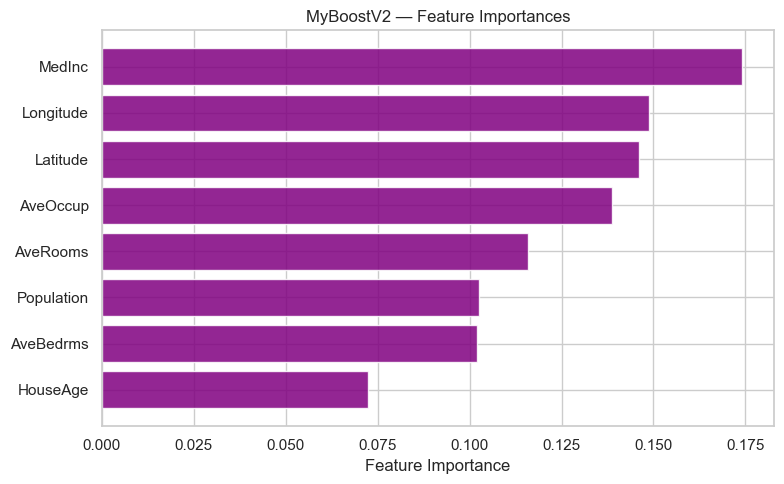

In [57]:
# Получаем важность признаков и визуализируем
feat_imp = mb2.feature_importances_
feature_names = X_train_full.columns.tolist() if hasattr(X_train_full, 'columns') else data.feature_names

fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': feat_imp
}).sort_values('importance', ascending = False)

print("Важность признаков (MyBoostV2):")
print(fi_df.to_string(index = False))
print(f"\nСумма importance: {feat_imp.sum():.6f}  (должна быть ≈ 1.0)")

plt.figure(figsize = (8, 5))
plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color = 'purple', alpha = 0.85)
plt.xlabel('Feature Importance')
plt.title('MyBoostV2 — Feature Importances')
plt.tight_layout()
plt.show()


#### Поддержка категориальных признаков

In [ ]:
# Демонстрируем нативную поддержку категориальных признаков
# Добавим синтетическую категориальную колонку в California Housing

X_cat = X_train_full.copy()
X_cat_test = X_test.copy()

# Бинаризуем AveOccup в три категории — имитируем реальный кейс
bins    = [0, 2.5, 3.5, np.inf]
labels  = ['low', 'medium', 'high']
X_cat['OccupLevel']      = pd.cut(X_cat['AveOccup'],      bins = bins, labels = labels)
X_cat_test['OccupLevel'] = pd.cut(X_cat_test['AveOccup'], bins = bins, labels = labels)

# Дропаем числовую версию, чтобы признак был именно категориальным
X_cat      = X_cat.drop(columns = ['AveOccup'])
X_cat_test = X_cat_test.drop(columns = ['AveOccup'])

print("Типы данных с категориальным признаком:")
print(X_cat.dtypes.to_string())
print(f"\nУникальные значения OccupLevel: {X_cat['OccupLevel'].unique().tolist()}")

mb_cat = MyBoostV2(n = 400, lr = 0.05, depth = 7, subsample = 0.8, colsample = 0.8, seed = 42)
mb_cat.fit(X_cat, y_train_full)
preds_cat = mb_cat.predict(X_cat_test)

rmse_cat = np.sqrt(mean_squared_error(y_test, preds_cat))
r2_cat   = r2_score(y_test, preds_cat)
print(f"\nMyBoostV2 + категориальный признак:")
print(f"  RMSE = {rmse_cat:.4f}")
print(f"  R²   = {r2_cat:.4f}")
print("OrdinalEncoder успешно применён внутри модели ✓")


Типы данных с категориальным признаком:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
Latitude       float64
Longitude      float64
OccupLevel    category

Уникальные значения OccupLevel: ['high', 'medium', 'low']


#### Влияние subsample и colsample на качество

In [ ]:
# Проверяем, как комбинации subsample / colsample влияют на RMSE и скорость
configs = [
    (1.0, 1.0,  "базовый (без стохастики)"),
    (0.8, 1.0,  "subsample=0.8"),
    (1.0, 0.8,  "colsample=0.8"),
    (0.8, 0.8,  "оба=0.8"),
    (0.6, 0.6,  "оба=0.6"),
]

print(f"{'Конфигурация':<30} {'RMSE':>7} {'R²':>7} {'Время, с':>10}")
print("─" * 60)

for sub, col, label in configs:
    m = MyBoostV2(n = 400, lr = 0.05, depth = 7,
                  subsample = sub, colsample = col, seed = 42)
    t0 = time.time()
    m.fit(X_train_full, y_train_full)
    elapsed = time.time() - t0
    p  = m.predict(X_test)
    r  = np.sqrt(mean_squared_error(y_test, p))
    r2 = r2_score(y_test, p)
    print(f"{label:<30} {r:>7.4f} {r2:>7.4f} {elapsed:>10.2f}")


Конфигурация                      RMSE      R²   Время, с
────────────────────────────────────────────────────────────
базовый (без стохастики)        0.4558  0.8415      73.42
subsample=0.8                   0.4507  0.8450      59.15
colsample=0.8                   0.4431  0.8502      55.01
оба=0.8                         0.4465  0.8478      44.15
оба=0.6                         0.4524  0.8438      22.64


---
### Бонус: `GBMClassifier` — бустинг для бинарной классификации

**Идея:** заменяем MSE-потери на логарифмические (log-loss / бинарная кросс-энтропия).

- Начальный прогноз: $F_0 = \log\left(\frac{\bar{y}}{1 - \bar{y}}\right)$ — логиты среднего
- Псевдо-остатки: $r_i = y_i - \sigma(F_i)$, где $\sigma(z) = \frac{1}{1+e^{-z}}$ — сигмоида
- Каждое дерево подгоняется к этим остаткам
- Итоговая вероятность: $P(y=1) = \sigma(F_n)$

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.datasets import load_breast_cancer

class GBMClassifier:
    """
    Градиентный бустинг для бинарной классификации.

    Использует log-loss как функцию потерь.
    Псевдо-остатки: r_i = y_i - sigmoid(F_i).
    Предсказывает вероятности через sigmoid(F_n).

    Параметры — те же, что у MyBoostV2.
    """

    def __init__(self, n = 400, lr = 0.05, depth = 5,
                 subsample = 0.8, colsample = 0.8, seed = 42):
        self.n         = n
        self.lr        = lr
        self.depth     = depth
        self.subsample = subsample
        self.colsample = colsample
        self.seed      = seed
        self.trees      = []
        self.col_indices = []
        self._encoder   = None

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

    def _encode(self, X, fit = False):
        if isinstance(X, np.ndarray):
            return X.astype(float)
        X = X.copy()
        cat_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
        if cat_cols:
            if fit:
                self._encoder = OrdinalEncoder(
                    handle_unknown = 'use_encoded_value', unknown_value = -1
                )
                X[cat_cols] = self._encoder.fit_transform(X[cat_cols])
            elif self._encoder is not None:
                X[cat_cols] = self._encoder.transform(X[cat_cols])
        return X.values.astype(float)

    def fit(self, X, y):
        rng = np.random.RandomState(self.seed)
        X_enc = self._encode(X, fit=True)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X_enc.shape

        # Начальный прогноз — логиты доли положительного класса
        p_mean = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.initial_leaf = np.log(p_mean / (1.0 - p_mean))

        F = np.full(n_samples, self.initial_leaf)

        self.trees, self.col_indices = [], []

        for i in range(self.n):
            # Псевдо-остатки = y - sigmoid(F)
            antigrad = y - self._sigmoid(F)

            # subsample
            row_idx = (rng.choice(n_samples,
                                   size = int(n_samples * self.subsample),
                                   replace = False)
                       if self.subsample < 1.0 else np.arange(n_samples))

            # colsample
            col_idx = (np.sort(rng.choice(n_features,
                                           size = max(1, int(n_features * self.colsample)),
                                           replace = False))
                       if self.colsample < 1.0 else np.arange(n_features))

            self.col_indices.append(col_idx)

            tree = DecisionTreeRegressor(
                max_depth = self.depth,
                random_state = self.seed + i,
                criterion = 'friedman_mse'
            )
            tree.fit(X_enc[np.ix_(row_idx, col_idx)], antigrad[row_idx])
            self.trees.append(tree)

            F += self.lr * tree.predict(X_enc[:, col_idx])

        return self

    def predict_proba(self, X):
        """Вероятности класса 1."""
        X_enc = self._encode(X, fit = False)
        F = np.full(len(X_enc), self.initial_leaf)
        for tree, col_idx in zip(self.trees, self.col_indices):
            F += self.lr * tree.predict(X_enc[:, col_idx])
        return self._sigmoid(F)

    def predict(self, X, threshold = 0.5):
        """Метки классов (порог по умолчанию = 0.5)."""
        return (self.predict_proba(X) >= threshold).astype(int)

    @property
    def feature_importances_(self):
        if not self.trees:
            raise RuntimeError("Модель не обучена.")
        n_features_total = max(idx.max() for idx in self.col_indices) + 1
        importances = np.zeros(n_features_total)
        for tree, col_idx in zip(self.trees, self.col_indices):
            importances[col_idx] += tree.feature_importances_ * self.lr
        total = importances.sum()
        return importances / total if total > 0 else importances


#### Проверка GBMClassifier на Breast Cancer Wisconsin

In [ ]:
# Breast Cancer — стандартный бинарный датасет (569 объектов, 30 признаков)
bc_data = load_breast_cancer()
X_bc = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
y_bc = bc_data.target

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size = 0.2, random_state = 42, stratify = y_bc
)

# ── Наш GBMClassifier ──
gc = GBMClassifier(n = 300, lr = 0.05, depth = 5, subsample = 0.8, colsample = 0.8, seed = 42)
t0 = time.time()
gc.fit(X_bc_train, y_bc_train)
t_gc = time.time() - t0

proba_gc  = gc.predict_proba(X_bc_test)
preds_gc  = gc.predict(X_bc_test)
acc_gc    = accuracy_score(y_bc_test, preds_gc)
auc_gc    = roc_auc_score(y_bc_test, proba_gc)
ll_gc     = log_loss(y_bc_test, proba_gc)

# ── XGBoost как эталон ──
xgb_cls = xgb.XGBClassifier(n_estimators = 300, learning_rate = 0.05,
                              max_depth = 5, subsample = 0.8,
                              random_state = 42, n_jobs = -1,
                              eval_metric = 'logloss', verbosity = 0)
xgb_cls.fit(X_bc_train, y_bc_train)
proba_xgb = xgb_cls.predict_proba(X_bc_test)[:, 1]
preds_xgb = xgb_cls.predict(X_bc_test)
acc_xgb = accuracy_score(y_bc_test, preds_xgb)
auc_xgb = roc_auc_score(y_bc_test, proba_xgb)
ll_xgb  = log_loss(y_bc_test, proba_xgb)

# ── Таблица результатов ──
cmp = pd.DataFrame([
    {"Модель": "GBMClassifier", "Accuracy": acc_gc, "ROC-AUC": auc_gc,
     "Log-Loss": round(ll_gc, 4), "Время, с": round(t_gc, 2)},
    {"Модель": "XGBoost", "Accuracy": acc_xgb, "ROC-AUC": auc_xgb,
     "Log-Loss": round(ll_xgb, 4), "Время, с": "—"},
])
display(cmp.round(4))

diff_auc = auc_gc - auc_xgb
print(f"\nРазница ROC-AUC: {diff_auc:+.4f}  (допуск по заданию ≥ −0.05)")
print(" Классификатор прошёл проверку " if diff_auc >= -0.05
      else "Классификатор заметно уступает XGBoost, нужна доработка.")


,Модель,Accuracy,ROC-AUC,Log-Loss,"Время, с"
0,GBMClassifier,0.9474,0.9931,0.1575,3.02
1,XGBoost,0.9561,0.9950,0.0872,—



Разница ROC-AUC: -0.0020  (допуск по заданию ≥ −0.05)
 Классификатор прошёл проверку


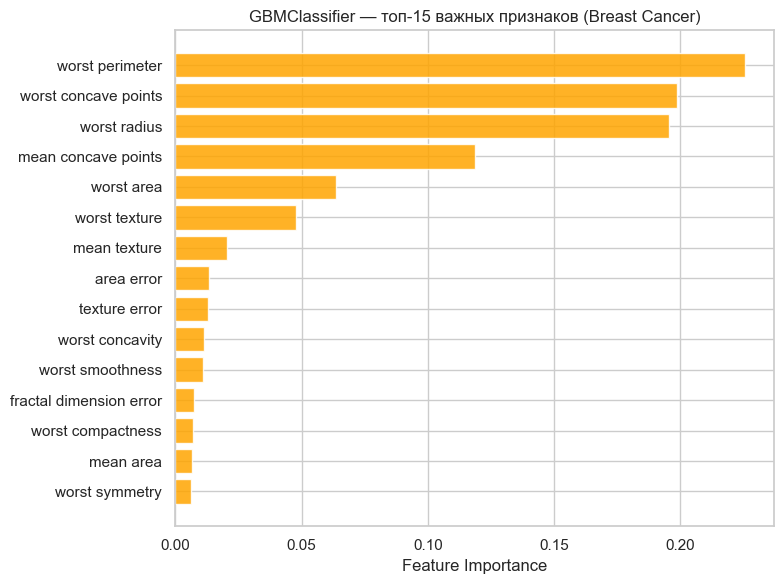

In [ ]:
# Feature importances для GBMClassifier
fi_clf = gc.feature_importances_
fi_clf_df = pd.DataFrame({
    'feature': bc_data.feature_names,
    'importance': fi_clf
}).sort_values('importance', ascending = False).head(15)

plt.figure(figsize =(8, 6))
plt.barh(fi_clf_df['feature'][::-1], fi_clf_df['importance'][::-1],
         color= 'orange', alpha = 0.85)
plt.xlabel('Feature Importance')
plt.title('GBMClassifier — топ-15 важных признаков (Breast Cancer)')
plt.tight_layout()
plt.show()


---
### Итоговое сравнение: MyBoostV2 vs XGBoost / LightGBM / CatBoost

In [ ]:
# Перезапускаем финальное сравнение с MyBoostV2 вместо исходного MyBoost
results_v2 = []

models_final = [
    ("XGBoost",    xgb.XGBRegressor(n_estimators = SELECTED_N_ESTIMATORS, random_state = 42,
                                     n_jobs = -1, **best_params_dict['XGBoost'])),
    ("LightGBM",   lgb.LGBMRegressor(n_estimators = SELECTED_N_ESTIMATORS, random_state = 42,
                                      n_jobs = -1, verbose = -1, **best_params_dict['LightGBM'])),
    ("CatBoost",   cb.CatBoostRegressor(iterations = SELECTED_N_ESTIMATORS, random_seed = 42,
                                         thread_count = -1, verbose = 0, **best_params_dict['CatBoost'])),
    ("MyBoostV2",  MyBoostV2(n = SELECTED_N_ESTIMATORS, lr = 0.05, depth = 7,
                              subsample = 0.8, colsample = 0.8, seed = 42)),
]

for name, model in models_final:
    t0 = time.time()
    model.fit(X_train_full, y_train_full)
    elapsed = time.time() - t0

    preds = model.predict(X_test)
    results_v2.append({
        "Модель":   name,
        "Время, с": round(elapsed, 2),
        "MAE": round(mean_absolute_error(y_test, preds), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        "R²": round(r2_score(y_test, preds), 4),
    })

df_v2 = pd.DataFrame(results_v2)
display(df_v2)

# Проверка допуска по заданию
xgb_r2   = df_v2.loc[df_v2['Модель'] == 'XGBoost',   'R²'].values[0]
my_r2    = df_v2.loc[df_v2['Модель'] == 'MyBoostV2',  'R²'].values[0]
diff_r2  = my_r2 - xgb_r2
print(f"\nR²(XGBoost)   = {xgb_r2:.4f}")
print(f"R²(MyBoostV2) = {my_r2:.4f}")
print(f"Разница: {diff_r2:+.4f}  (допуск по заданию ≥ −0.05)")
print(" Реализация прошла проверку" if diff_r2 >= -0.05
      else " нужна доработка.")


,Модель,"Время, с",MAE,RMSE,R²
0,XGBoost,3.87,0.2888,0.4440,0.8496
1,LightGBM,1.25,0.2862,0.4379,0.8537
2,CatBoost,6.05,0.2967,0.4493,0.8460
3,MyBoostV2,45.51,0.2923,0.4465,0.8478



R²(XGBoost)   = 0.8496
R²(MyBoostV2) = 0.8478
Разница: -0.0018  (допуск по заданию ≥ −0.05)
 Реализация прошла проверку


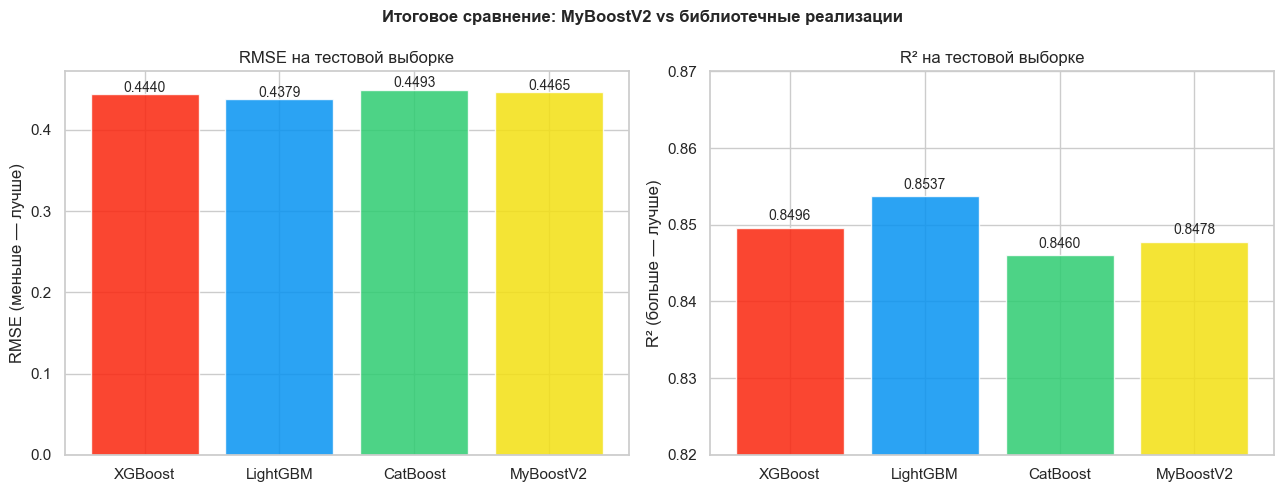

In [ ]:
# Визуализация итогового сравнения
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

models_labels = df_v2['Модель'].tolist()
colors = ["#fa250d", "#0693f1", '#2ecc71', "#f3e012"]

# RMSE
axes[0].bar(models_labels, df_v2['RMSE'], color = colors, alpha = 0.85)
axes[0].set_ylabel('RMSE (меньше — лучше)')
axes[0].set_title('RMSE на тестовой выборке')
for i, v in enumerate(df_v2['RMSE']):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha = 'center', fontsize = 10)

# R²
axes[1].bar(models_labels, df_v2['R²'], color = colors, alpha = 0.85)
axes[1].set_ylabel('R² (больше — лучше)')
axes[1].set_title('R² на тестовой выборке')
axes[1].set_ylim(0.82, 0.87)
for i, v in enumerate(df_v2['R²']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha = 'center', fontsize = 10)

plt.suptitle('Итоговое сравнение: MyBoostV2 vs библиотечные реализации',
             fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()
